## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

## **Load Processed Data**

In [21]:
df_raw = pd.read_csv("dataset/raw/train.csv")

In [24]:
df_processed = pd.read_csv("dataset/processed/train_processed.csv")

In [25]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492096 entries, 0 to 2492095
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Temperature(F)     float64
 1   Humidity(%)        float64
 2   Visibility(mi)     float64
 3   Amenity            bool   
 4   City               object 
 5   County             object 
 6   Crossing           bool   
 7   Junction           bool   
 8   Railway            bool   
 9   Start_Time         object 
 10  State              object 
 11  Station            bool   
 12  Stop               bool   
 13  Sunrise_Sunset     object 
 14  Traffic_Signal     bool   
 15  Weather_Condition  object 
 16  Severity           int64  
dtypes: bool(7), float64(3), int64(1), object(6)
memory usage: 206.8+ MB


In [26]:
pd.set_option('display.max_columns', None)
df_processed.head()

,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition,Severity
0,63.0,66.0,10.0,False,Hillsborough,Orange,False,False,False,2022-03-18 06:55:00,NC,False,False,Night,False,Cloudy,4
1,41.0,93.0,10.0,False,Auburn,Placer,False,False,False,2023-01-29 16:35:00,CA,False,True,Day,False,Cloudy,2
2,71.0,32.0,10.0,False,Richmond,Richmond City,True,False,False,2022-10-11 12:53:40,VA,False,False,Day,True,Fair,2
3,26.0,99.0,10.0,False,Newport News,Newport News,False,True,False,2022-01-24 06:12:00,VA,False,False,Night,False,Fair,2
4,64.0,52.0,10.0,False,Sacramento,Sacramento,False,True,False,2020-02-14 15:28:00,CA,False,False,Day,False,Fair,2


## Columns Split

In [27]:
numerical_vars = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df_processed.select_dtypes(include=['object']).columns.tolist()
boolean_vars = df_processed.select_dtypes(include=['bool']).columns.tolist()

In [28]:
print("\nNumerical Columns:", numerical_vars)
print("\nCategorical Columns:", categorical_vars)
print("\nBoolean Columns:", boolean_vars)


Numerical Columns: ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Severity']

Categorical Columns: ['City', 'County', 'Start_Time', 'State', 'Sunrise_Sunset', 'Weather_Condition']

Boolean Columns: ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']


In [29]:
numerical_data = df_processed[numerical_vars]
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,Temperature(F),Humidity(%),Visibility(mi),Severity
count,2492096.00,2492096.00,2492096.00,2492096.00
mean,60.96,63.74,9.09,2.08
std,19.03,22.79,2.57,0.41
min,-50.00,1.00,0.00,1.00
25%,49.00,47.00,10.00,2.00
50%,63.00,66.00,10.00,2.00
75%,75.00,83.00,10.00,2.00
max,130.00,100.00,140.00,4.00


In [30]:
categorical_data = df_processed[categorical_vars]
print ("Categorical Data Description:")
categorical_data.describe().round(2)

Categorical Data Description:


,City,County,Start_Time,State,Sunrise_Sunset,Weather_Condition
count,2492096,2492096,2492096,2492096,2492096,2492096
unique,11521,1745,1636414,49,2,122
top,Miami,Los Angeles,2021-01-26 16:16:13,CA,Day,Fair
freq,92617,183782,181,659581,1593692,1157228


In [31]:
boolean_data = df_processed[boolean_vars]
print ("Boolean Data Description:")
boolean_data.describe().round(2)

Boolean Data Description:


,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal
count,2492096,2492096,2492096,2492096,2492096,2492096,2492096
unique,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False
freq,2464177,2260487,2290332,2472483,2424135,2428371,2259034


## **Check for Missing Values**

In [32]:
missing_count = missing_count = df_processed.isnull().sum()
missing_percent = (missing_count / len(df_processed) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Temperature(F),0,0.0
Start_Time,0,0.0
Weather_Condition,0,0.0
Traffic_Signal,0,0.0
Sunrise_Sunset,0,0.0
Stop,0,0.0
Station,0,0.0
State,0,0.0
Railway,0,0.0
Humidity(%),0,0.0


After cleaning the dataset, all selected variables show 0 missing values, meaning the data is now fully complete across every field. This ensures that subsequent analysis, modeling, and visualization can proceed without the need for imputation or additional preprocessing related to missing data.

## Outlier Detection

In [54]:
# Detect outliers using the IQR method
Q1 = df_processed[numerical_vars].quantile(0.25)
Q3 = df_processed[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_processed[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df_processed[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Temperature(F)     22123
Humidity(%)            0
Visibility(mi)    462300
Severity          169713
dtype: int64


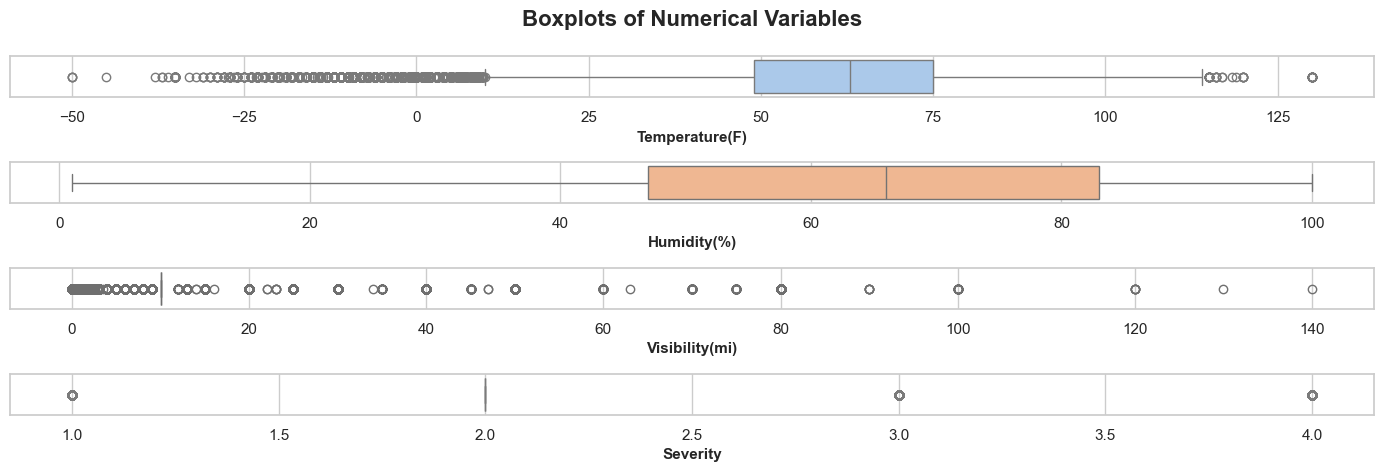

In [34]:
n = len(numerical_vars)

plt.figure(figsize=(14, n * 1.2))

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df_processed[col],
        orient='h',
        color=palette_color[i - 1]
    )
    plt.xlabel(col, fontweight='bold', fontsize=11)

plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

After cleaning, the number of outliers decreases in some fields (**Temperature(F), Severity**) due to transformations or filtering.
However, **Visibility(mi)** still contains many outliers. These values were not removed intentionally, because low visibility is a realistic condition in accident scenarios and directly contributes to crash risk. These are meaningful observations, not invalid data points, so they remain in the dataset.

## VIF Check

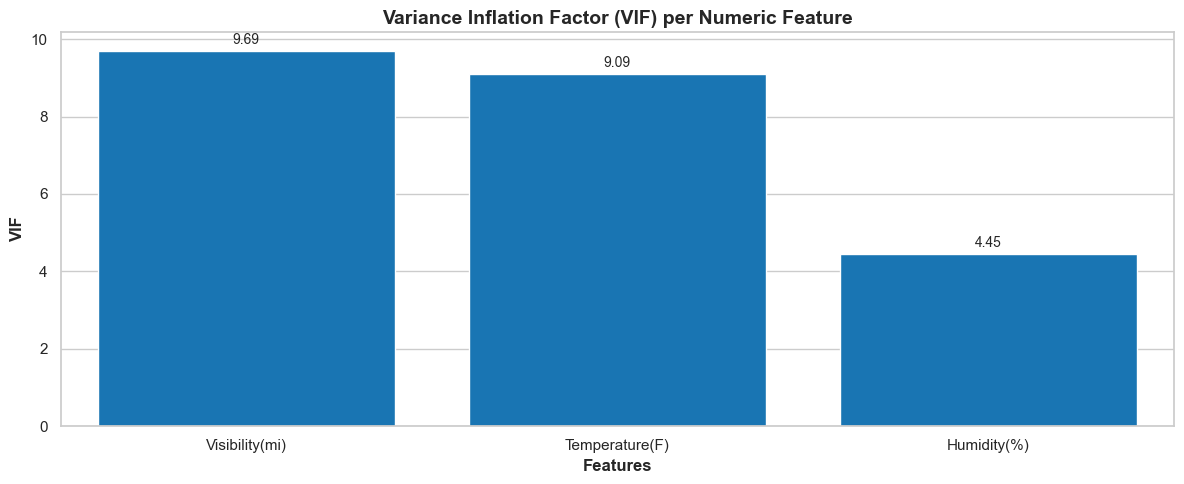

In [35]:
target_var = 'Severity'
X_numeric = df_processed[numerical_vars].drop(columns=[target_var])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(x='Feature', y='VIF', data=vif_data, color='#007acc')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)
    
plt.xticks(rotation=0, ha='center')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('VIF', fontsize=12, fontweight='bold')
plt.title('Variance Inflation Factor (VIF) per Numeric Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

After cleaning and processing, only three core numeric features remained for VIF testing.
- **Visibility** and **Temperature** have VIF close to 10, showing strong multicollinearity, meaning these weather variables still influence each other even after processing.
- **Humidity** has moderate correlation.
> Overall, the processed dataset is cleaner but still shows expected relationships between weather metrics.

## **Univariate Analysis**

## Numerical features distribution

In [57]:
def plot_comparison_hist(column, df1, df2, color1="#5da8db", color2='orange', figsize=(14,5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for ax, df, title, color in zip(axes, [df1, df2], [f'{column} - Data raw', f'{column} - Data processed'], [color1, color2]):
        sns.histplot(df[column], kde=True, bins=50, ax=ax, color=color, alpha=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel(column, fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.axvline(df[column].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df[column].mean():.2f}')
        ax.axvline(df[column].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df[column].median():.2f}')
        ax.legend(loc='upper right')
    
    x_min = min(df1[column].min(), df2[column].min())
    x_max = max(df1[column].max(), df2[column].max())
    for ax in axes:
        ax.set_xlim(x_min, x_max)
    
    plt.tight_layout()
    plt.show()

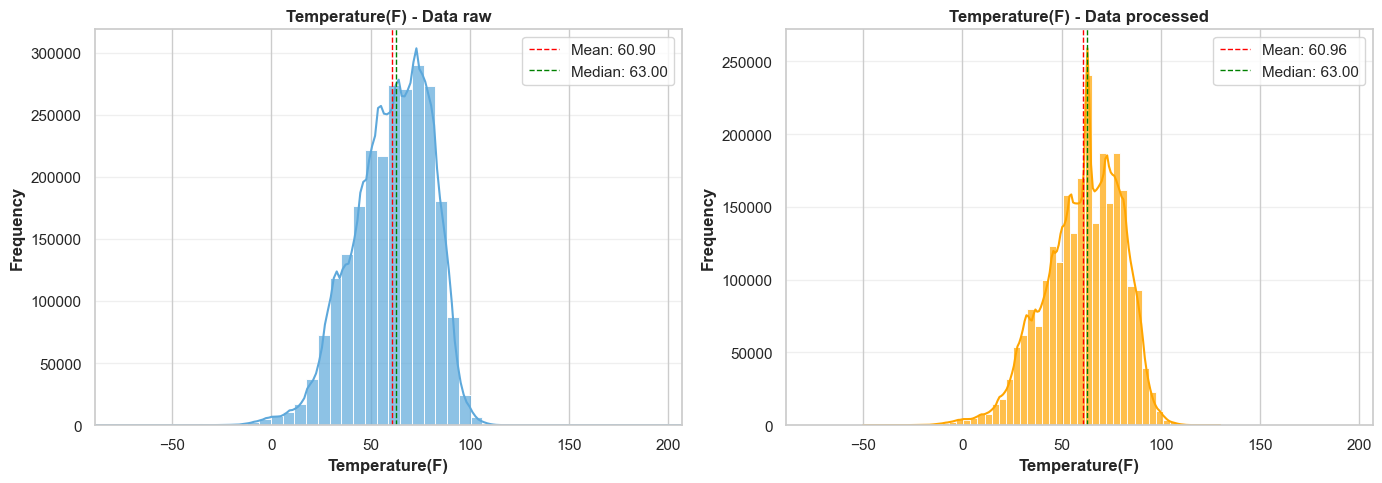

In [58]:
plot_comparison_hist('Temperature(F)', df_raw, df_processed)

### Temperature(F) – Data After Processing Review
**Preservation of Data Distribution**
- Outlier capping and missing value imputation successfully cleaned the data while preserving its integrity.
- The overall bell-curve shape is maintained after preprocessing, showing that the data’s underlying structure was not distorted.  
- Statistical stability:
  - **Mean:** 60.90 → 60.96  
  - **Median:** 63.00 (unchanged)  
  These minimal changes confirm that the preprocessing was accurate and light-touch.

**Explanation of Distribution Changes**
- Tail truncation due to outlier capping: 
  - **Raw data:** Long tails at both ends, including physically impossible extremes.  
  - **Processed data:** Extreme values capped at the defined boundaries.  
- Visual effect: The histogram of processed data appears more compact, with steeper sides at the edges due to removed outliers.

> After removing the extreme values, the temperatures are concentrated mainly around 60–65°F, indicating that most accidents occur in moderate temperature conditions, neither too hot nor too cold.
> Values ​​outside the range [-50°F, 130°F] are extremely rare and unrealistic, indicating that extreme weather conditions are not a common cause of accidents in this dataset.

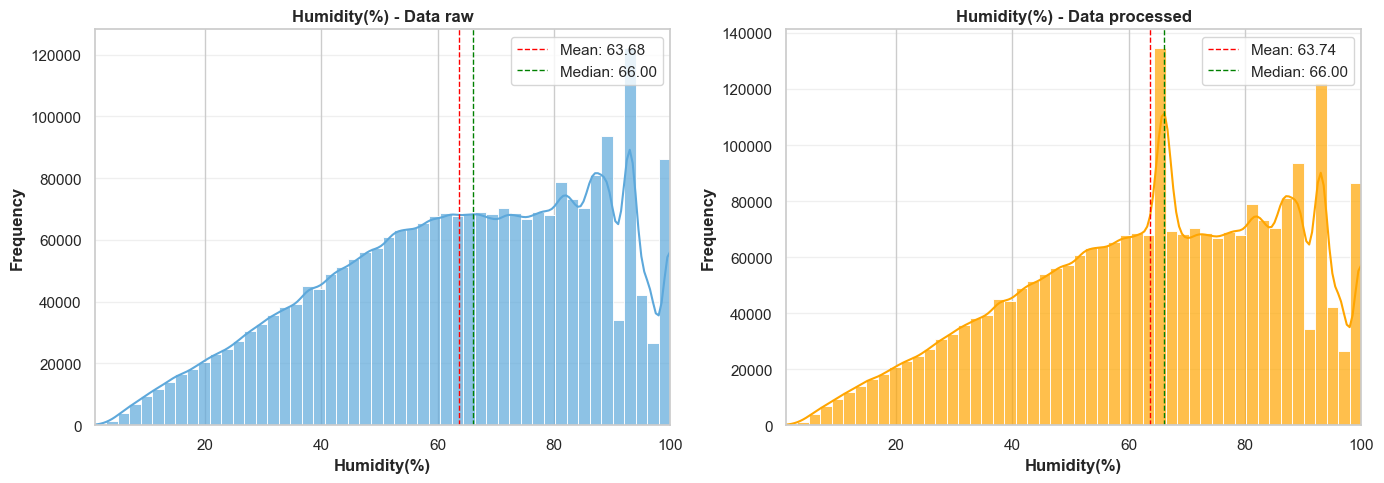

In [59]:
plot_comparison_hist('Humidity(%)', df_raw, df_processed)


### Humidity(%) – Data After Processing Review
**Preservation of Data Distribution**
- The data processing procedure, which included filling in missing values ​​with Median and handling outliers with Capping/Winsorization, worked very well. The overall shape of the data remains intact, without distortion, ensuring that the physical nature of the Humidity is not altered.
- Statistical stability:
  - **Mean:** 63.68 → 63.74 
  - **Median:** 66.00 (unchanged)  

**Explanation of Distribution Changes**
The processed histogram shows a sharp spike at the median value (Median ≈ 66%), forming a noticeable “peak” compared to the original histogram. This spike results from imputing missing values with the median. All NaN values were replaced with 66%, which significantly increased the frequency of this value.

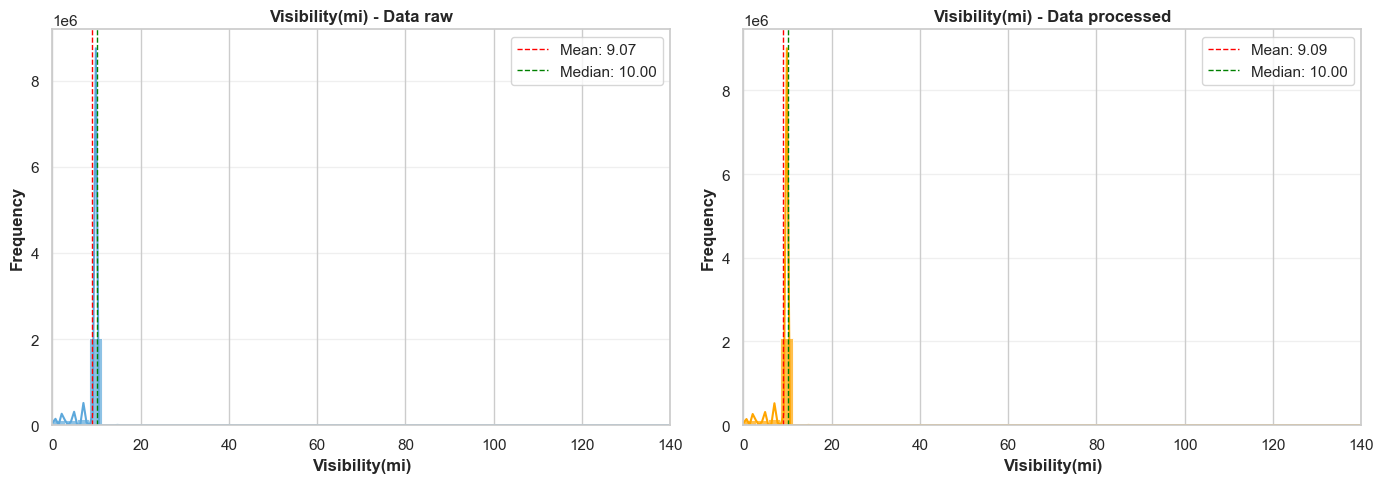

In [60]:
plot_comparison_hist('Visibility(mi)', df_raw, df_processed)

### Visibility (mi) – Data After Processing Review

**Visibility (mi)**
Before treatment: distribution is very right skewed — mostly concentrated at low levels (near 10 mi or lower) but there are some large outliers causing long tails; mean ≈ 9.07, median = 10.

After treatment: mean ≈ 9.09, median = 10 — center unchanged; post-treatment distribution is similarly right skewed but density curve is smoother, extremely large tails may have been treated/denoised.

> Treatment did not change the center position, but cleaned up large outliers/unwanted fluctuations.


## Categorical features distribution

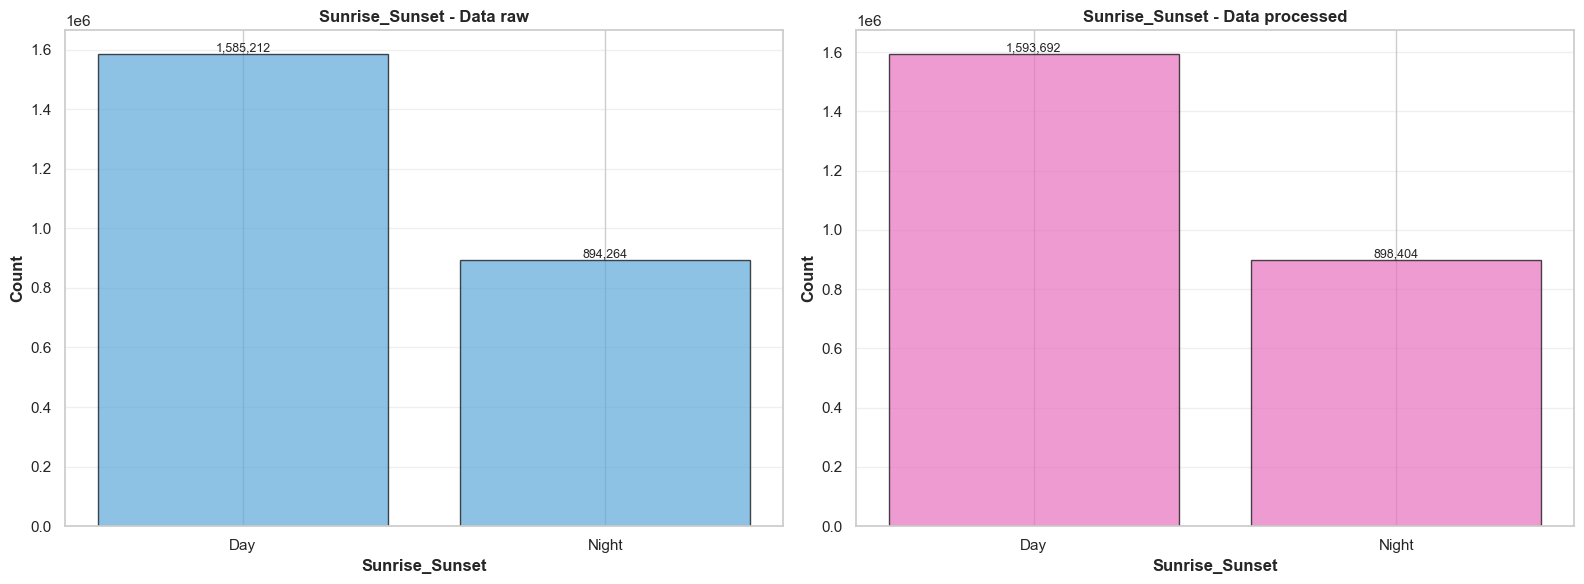

In [63]:
def plot_categorical_comparison(column, df1, df2, color1="#5da8db", color2='#e871c0', figsize=(16,6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for ax, df, title, color in zip(axes, [df1, df2], [f'{column} - Data raw', f'{column} - Data processed'], [color1, color2]):
        value_counts = df[column].value_counts()
        ax.bar(range(len(value_counts)), value_counts.values, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel(column, fontweight='bold')
        ax.set_ylabel('Count', fontweight='bold')
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=0, ha='center')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on top of bars
        for i, v in enumerate(value_counts.values):
            ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

plot_categorical_comparison('Sunrise_Sunset', df_raw, df_processed)


### Sunset_Sunrise – Data After Processing Review
**Preservation of Data Distribution**
- In both stages, the number of records occurring during the Day is nearly twice as high as those at Night. This indicates that accidents or events in the dataset tend to happen more frequently during daytime. 
- After handling missing values, the number of records increases slightly. This uniform increase demonstrates that the imputation or cleaning process did not distort the original distribution, ensuring safe and unbiased data handling.

**Explanation of Distribution Unchanges**
The Day/Night ratio remains almost unchanged. This confirms that the missing-value treatment did not introduce any new bias into the dataset.

> The insight remains the same: Accidents still happen much more frequently during the day than at night. This continues to be consistent with real-world logic: daytime traffic volumes are much higher, even though nighttime driving conditions are more dangerous.

## **Multivariate Analysis**

In [66]:
df_processed.head()

,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition,Severity
0,63.0,66.0,10.0,False,Hillsborough,Orange,False,False,False,2022-03-18 06:55:00,NC,False,False,Night,False,Cloudy,4
1,41.0,93.0,10.0,False,Auburn,Placer,False,False,False,2023-01-29 16:35:00,CA,False,True,Day,False,Cloudy,2
2,71.0,32.0,10.0,False,Richmond,Richmond City,True,False,False,2022-10-11 12:53:40,VA,False,False,Day,True,Fair,2
3,26.0,99.0,10.0,False,Newport News,Newport News,False,True,False,2022-01-24 06:12:00,VA,False,False,Night,False,Fair,2
4,64.0,52.0,10.0,False,Sacramento,Sacramento,False,True,False,2020-02-14 15:28:00,CA,False,False,Day,False,Fair,2


## Location Features vs Severity

In [ ]:
def plot_categorical_comparison(df1, df2, categorical_cols, colors=None, top_n=10):
    colors = colors or ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    for feature in categorical_cols:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        for ax, df, title in zip(axes, [df1, df2], ['Raw', 'Processed']):
            if df[feature].nunique() > top_n:
                top_categories = df[feature].value_counts().head(top_n).index[::-1]
                plot_df = df[df[feature].isin(top_categories)]
                title_suffix = f' (Top {top_n})'
            else:
                plot_df = df
                top_categories = None
                title_suffix = ''
            
            severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)
            if top_categories is not None:
                severity_counts = severity_counts.reindex(top_categories)
            severity_counts = severity_counts.reindex(columns=[1,2,3,4], fill_value=0)[[4,3,2,1]]
            
            severity_counts.plot(kind='barh', ax=ax, stacked=False, logx=True, width=0.8, color=colors)
            ax.set_title(f'{feature} vs Severity - {title}{title_suffix}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Count (Log Scale)', fontweight='bold')
            ax.set_ylabel(feature, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[::-1], labels[::-1], title='Severity', fontsize=9, loc='lower right')
        
        plt.tight_layout()
        plt.show()

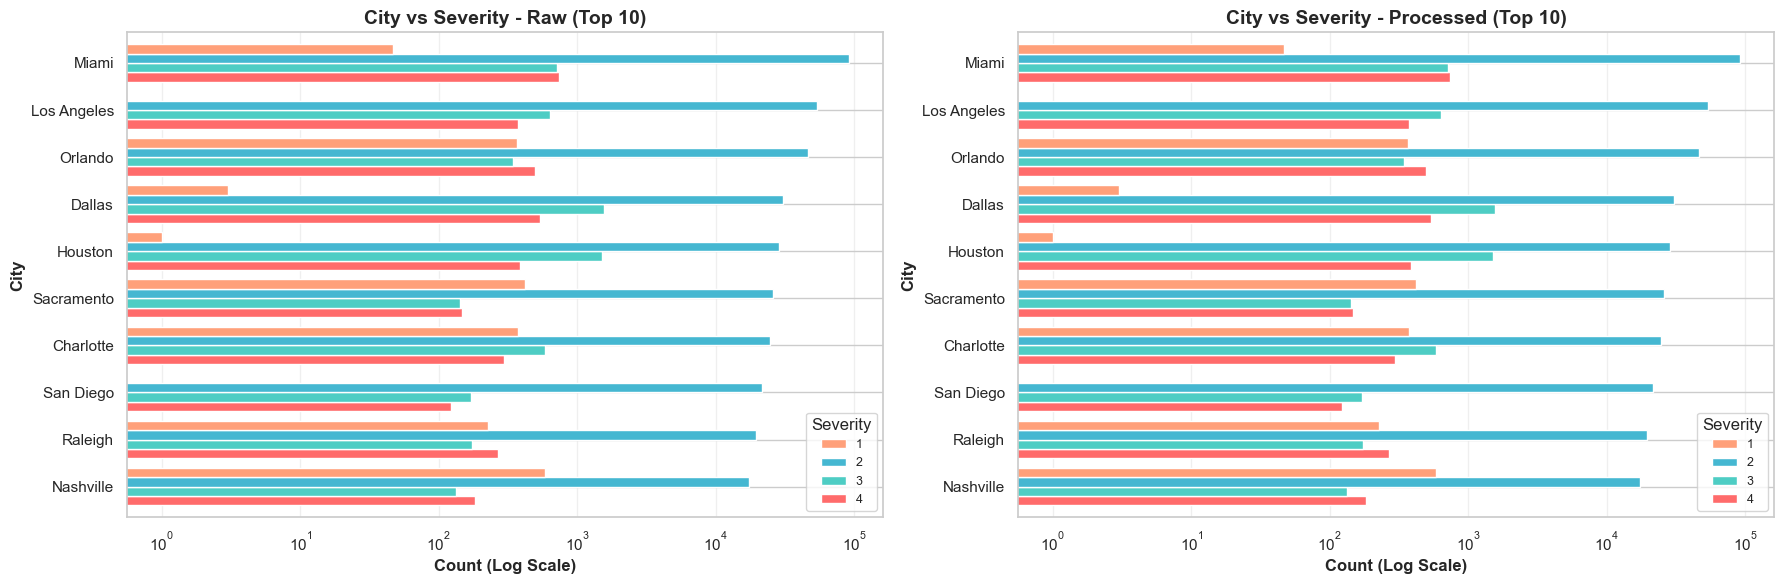

In [71]:
plot_categorical_comparison(df_raw, df_processed, ['City'])

- **Data Quality Check**
    + Stability (Consistency): The rankings and proportions of cities in the Processed chart are almost identical to those in the Raw data.
    + Information Preservation: The lengths of the bars in the chart show no sudden drops. This confirms that the data cleaning process (handling Missing Values, standardizing names) has preserved the core geographic structure of the dataset without distorting the real distribution.
- **Severity Distribution Analysis**
    + Dominance of Severity 2: In most major cities (such as Miami, Los Angeles...), Severity 2 is the most dominant group. This is a common feature of traffic accident data in urban areas (usually minor collisions, local congestion).
    + Severity 3 & 4: Thanks to the logarithmic scale, we can clearly see the presence of more serious accidents (Severity 3, 4). Although their numbers are hundreds of times fewer than Severity 2, they still consistently appear in large cities, reflecting the actual risk at busy intersections.

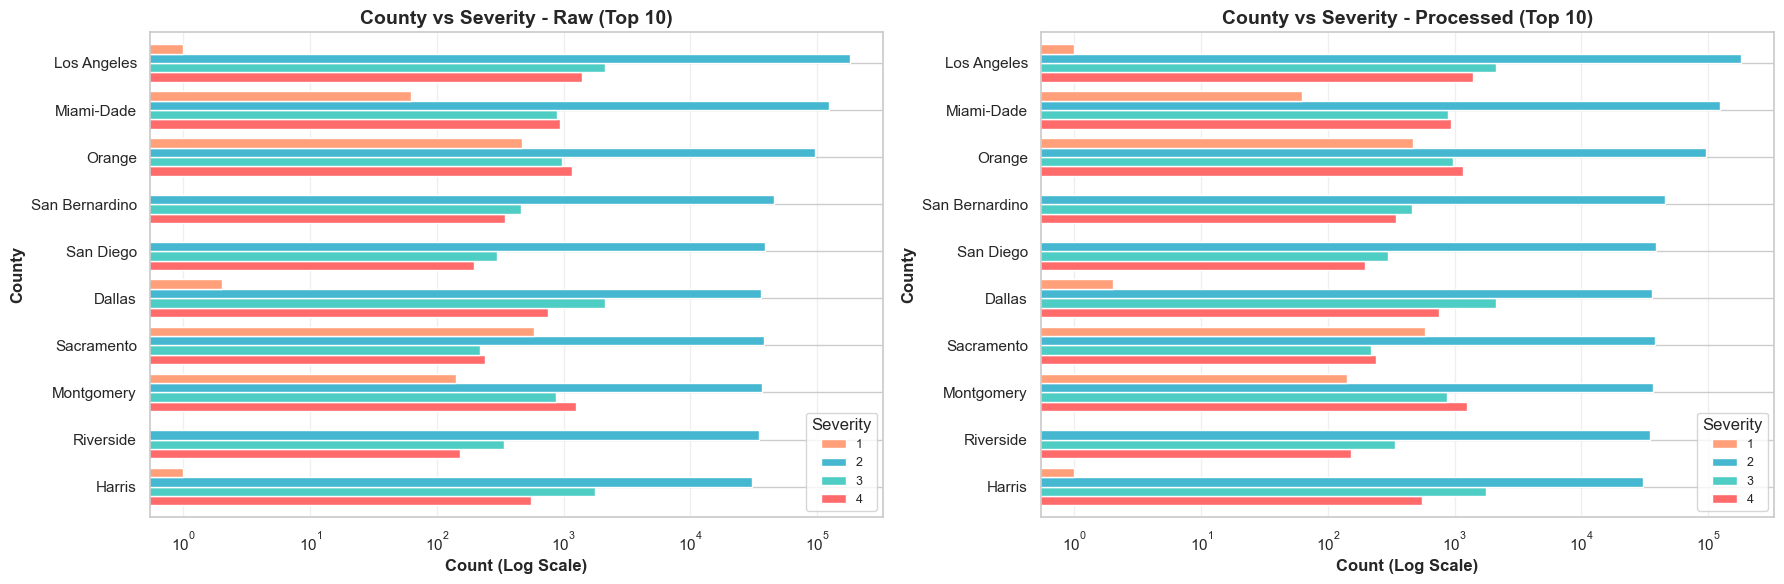

In [69]:
plot_categorical_comparison(df_raw, df_processed, ['County'])

- **Data Stability**
    + Processing Results: The data structure is fully preserved. The rankings of major Counties (e.g., Los Angeles County, Miami-Dade County...) remain unchanged after the preprocessing step.
    + Meaning: The data processing (such as filling missing values) does not distort the regional geographic characteristics.
- **Difference Compared to the City Feature**: Unlike the City feature (which tends to be fragmented into smaller segments), the County feature has a higher level of aggregation:
    + Broader Coverage: A County typically includes multiple cities and even inter-county highway areas (unincorporated areas). Therefore, County-level data provides a more accurate reflection of the traffic management area.
    + Higher Density: The number of accidents in top Counties is usually more "concentrated" compared to top Cities, making it easier for the model to learn the broader patterns.
- **Severity Analysis**
    + Severity 2 Dominance: Similar to the city level, at the County level, Severity 2 still dominates overwhelmingly.
    + Severity 3 & 4: By aggregating data at the County level, the number of Severity 4 incidents becomes more statistically significant compared to when data is broken down by city. This makes it easier to observe "hot spots" for serious accidents.

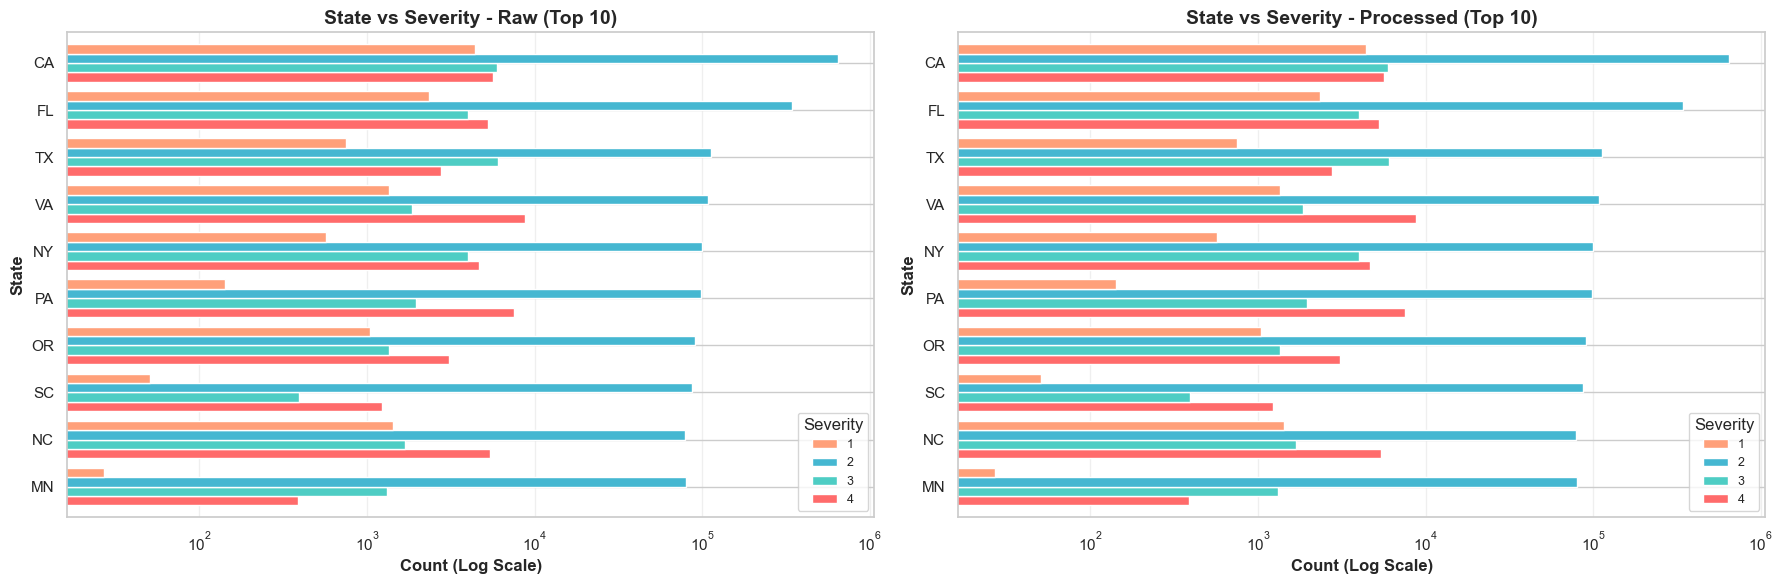

In [72]:
plot_categorical_comparison(df_raw, df_processed, ['State'])

- **Data Integrity:** The rankings of states with the highest number of accidents (typically CA - California, TX - Texas, FL - Florida) remain unchanged between the two charts.
- **Geographic Distribution Characteristics**
    + Significant Imbalance: The data is heavily concentrated in the top 3-5 most populous states with complex transportation systems (CA, TX, FL, NY).
    + Data Collection Factors: It's important to note that the high accident numbers in CA or TX may not only be due to population size, but also because the data sources in these regions are more up-to-date, and the traffic sensor systems are more dense compared to other states.
- **Severity Analysis by State**
    + Severity 2 Dominance: Similar to City and County levels, Severity 2 still overwhelmingly dominates in all states.
    + Differences in Severity 3 & 4 Ratios:
        + Some states with mountainous terrain or harsh climates (snow, ice) may have higher ratios of Severity 3 or 4 compared to flatland states.
        + This difference suggests that the State feature is not only an administrative region, but also acts as a proxy feature for climate, terrain, and traffic laws of that region.
        
**Insight:** The State feature is a baseline feature. However, to predict Severity accurately, the model needs to incorporate weather and time features, because the name "California" itself does not cause accidents, but "Fog in California at 8 a.m." is the real cause.

## Road Condition feature vs Severity

## **Correlation Matrix**

### Correlation Matrix for Numerical Features

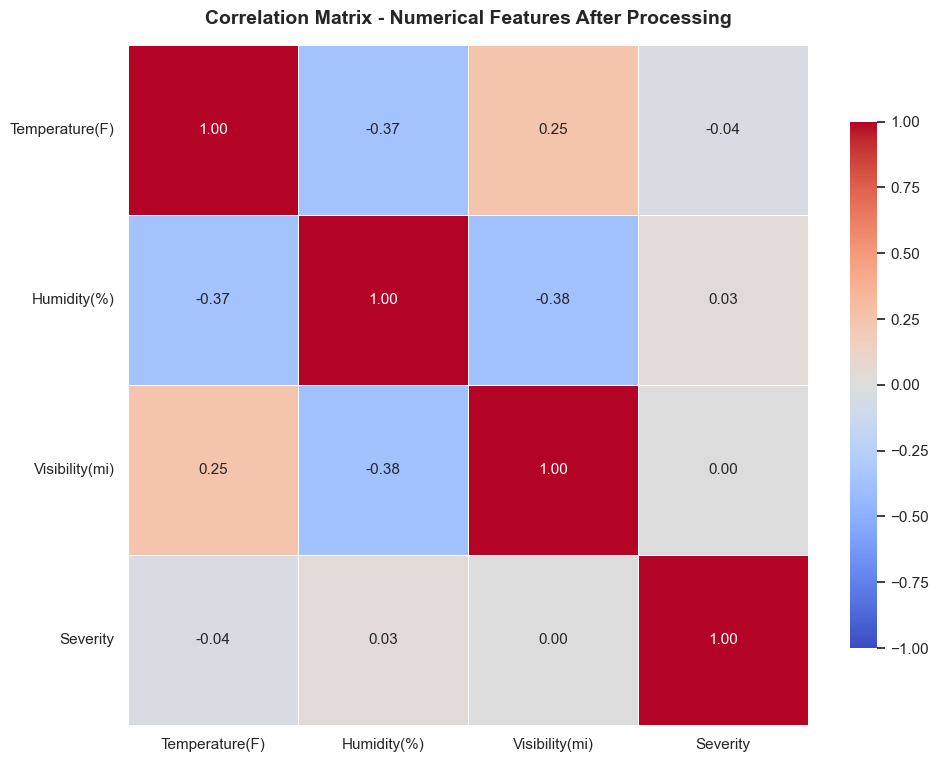

Highly Correlated Feature Pairs (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [ ]:
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_processed[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=-1, vmax=1,
            annot_kws={"size": 11})

plt.title('Correlation Matrix - Numerical Features After Processing', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Highly Correlated Feature Pairs (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

- **Temperature:** outliers are reduced/removed, distribution is smoother around 50–80.

- **Humidity:** distribution is smoother; large spikes are still present in the high region (90–100) if it is real data.

- **Visibility:** extreme tails are cleaned/denoised; distribution is still skewed right but “cleaner”.

- **Distance:** outliers have been removed/removed from analysis (due to large skew/outlier), so they do not appear in processed EDA.

**Correlation (post-processing)**
The relationships between Weather features remain: **Temp–Hum** ≈ -0.37, **Hum–Vis** ≈ -0.38, **Temp–Vis** ≈ 0.25.

**Severity** is still almost not linearly correlated with these variables (**Severity–Temp** ≈ -0.04, **–Hum** ≈ 0.03, **–Vis** ≈ 0.00).
Remark: data processing has cleaned but does not change the nature of the linear relationship between features and targets.

### Correlation Matrix for Categorical Features (Cramér's V)

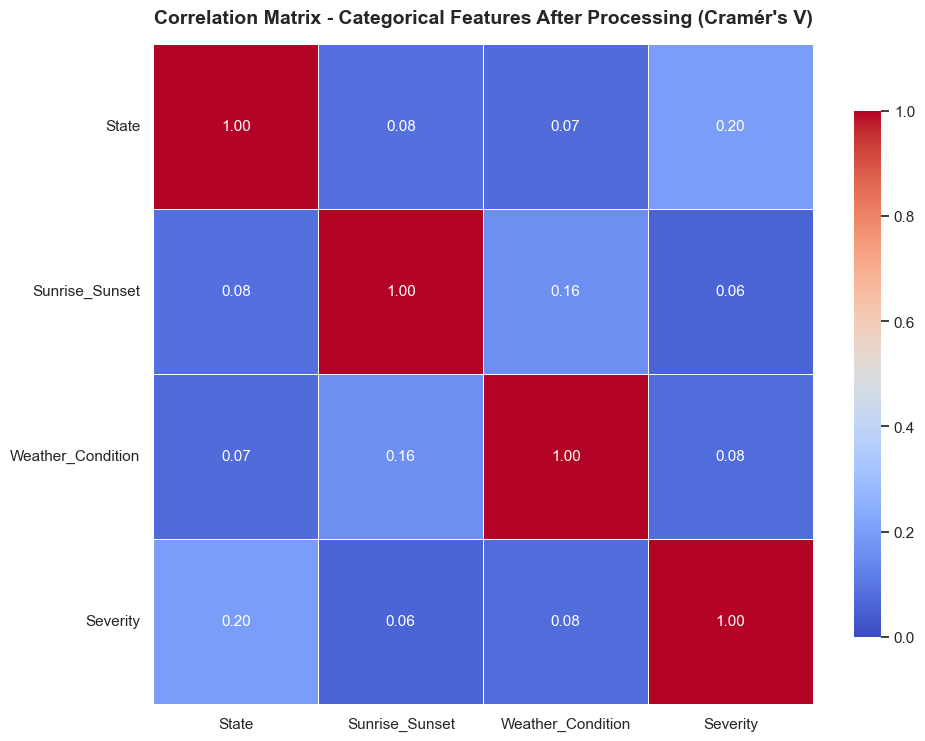

Strongly Associated Categorical Pairs (Cramér's V > 0.5)

No categorical pairs with Cramér's V > 0.5 found.


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Returns a value between 0 and 1, where:
    - 0 = no association
    - 1 = perfect association
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0
    
    cramers_v_stat = np.sqrt(chi2 / (n * min_dim))
    return cramers_v_stat

# Select categorical features (exclude high cardinality and ID-like columns)
categorical_cols_for_corr = df_processed.select_dtypes(include=['object']).columns.drop(
    ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 
     'Weather_Timestamp', 'City', 'County', 'Airport_Code'], errors='ignore'
).tolist()

# Add Severity to analyze its relationship with categorical features
if 'Severity' not in categorical_cols_for_corr:
    categorical_cols_for_corr.append('Severity')

# Calculate Cramér's V for all pairs
n_features = len(categorical_cols_for_corr)
cramers_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i == j:
            cramers_matrix[i, j] = 1.0
        elif i < j:
            v = cramers_v(df_processed[categorical_cols_for_corr[i]], 
                         df_processed[categorical_cols_for_corr[j]])
            cramers_matrix[i, j] = v
            cramers_matrix[j, i] = v

cramers_df = pd.DataFrame(cramers_matrix, 
                          index=categorical_cols_for_corr, 
                          columns=categorical_cols_for_corr)

# Visualize
plt.figure(figsize=(10, 8))

sns.heatmap(cramers_df, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0.5,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=0, vmax=1,
            annot_kws={"size": 11})

plt.title("Correlation Matrix - Categorical Features After Processing (Cramér's V)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Strongly Associated Categorical Pairs (Cramér's V > 0.5)")

strong_associations = []
for i in range(len(categorical_cols_for_corr)):
    for j in range(i+1, len(categorical_cols_for_corr)):
        v_value = cramers_df.iloc[i, j]
        if v_value > 0.5:
            strong_associations.append((
                categorical_cols_for_corr[i], 
                categorical_cols_for_corr[j], 
                v_value
            ))

if strong_associations:
    for var1, var2, v_val in sorted(strong_associations, key=lambda x: x[2], reverse=True):
        print(f"{var1:5s} <-> {var2:5s} : {v_val:.3f}")
else:
    print("\nNo categorical pairs with Cramér's V > 0.5 found.")

- **Temperature:** abnormal tail reduced, distribution smoother around 50–80.
- **Humidity:** distribution smoother, highland spikes still present if it is real data.
- **Visibility:** large outliers have been reduced/removed, distribution still skewed right but cleaner.
- **Distance:** removed (no longer processed), avoids the influence of large outliers.

**Correlation observations (post-processing)**
The relationships between weather features remain the same size: **Temp–Hum** ≈ -0.37, **Hum–Vis** ≈ -0.38, **Temp–Vis** ≈ 0.25.
**Severity** is still almost non-linearly correlated with post-processing variables (**Severity–Temp** ≈ -0.04, **–Hum** ≈ 0.03, –Vis ≈ 0.00).
In categorical terms, removing **Timezone** eliminated the very strong State–Timezone correlation; **State ↔ Severity** still ≈ 0.20; **Weather_Condition ↔ Sunrise_Sunset** ≈ 0.16.